
# Multiple Linear Regression Assignment

This notebook performs Multiple Linear Regression (MLR) analysis on the Toyota Corolla dataset.


In [1]:

# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:

# Load Dataset

df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display first 5 rows
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:

# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()


In [ ]:

# Check Missing Values

print(df.isnull().sum())



# Exploratory Data Analysis (EDA)


In [3]:

# Statistical Summary

df.describe()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


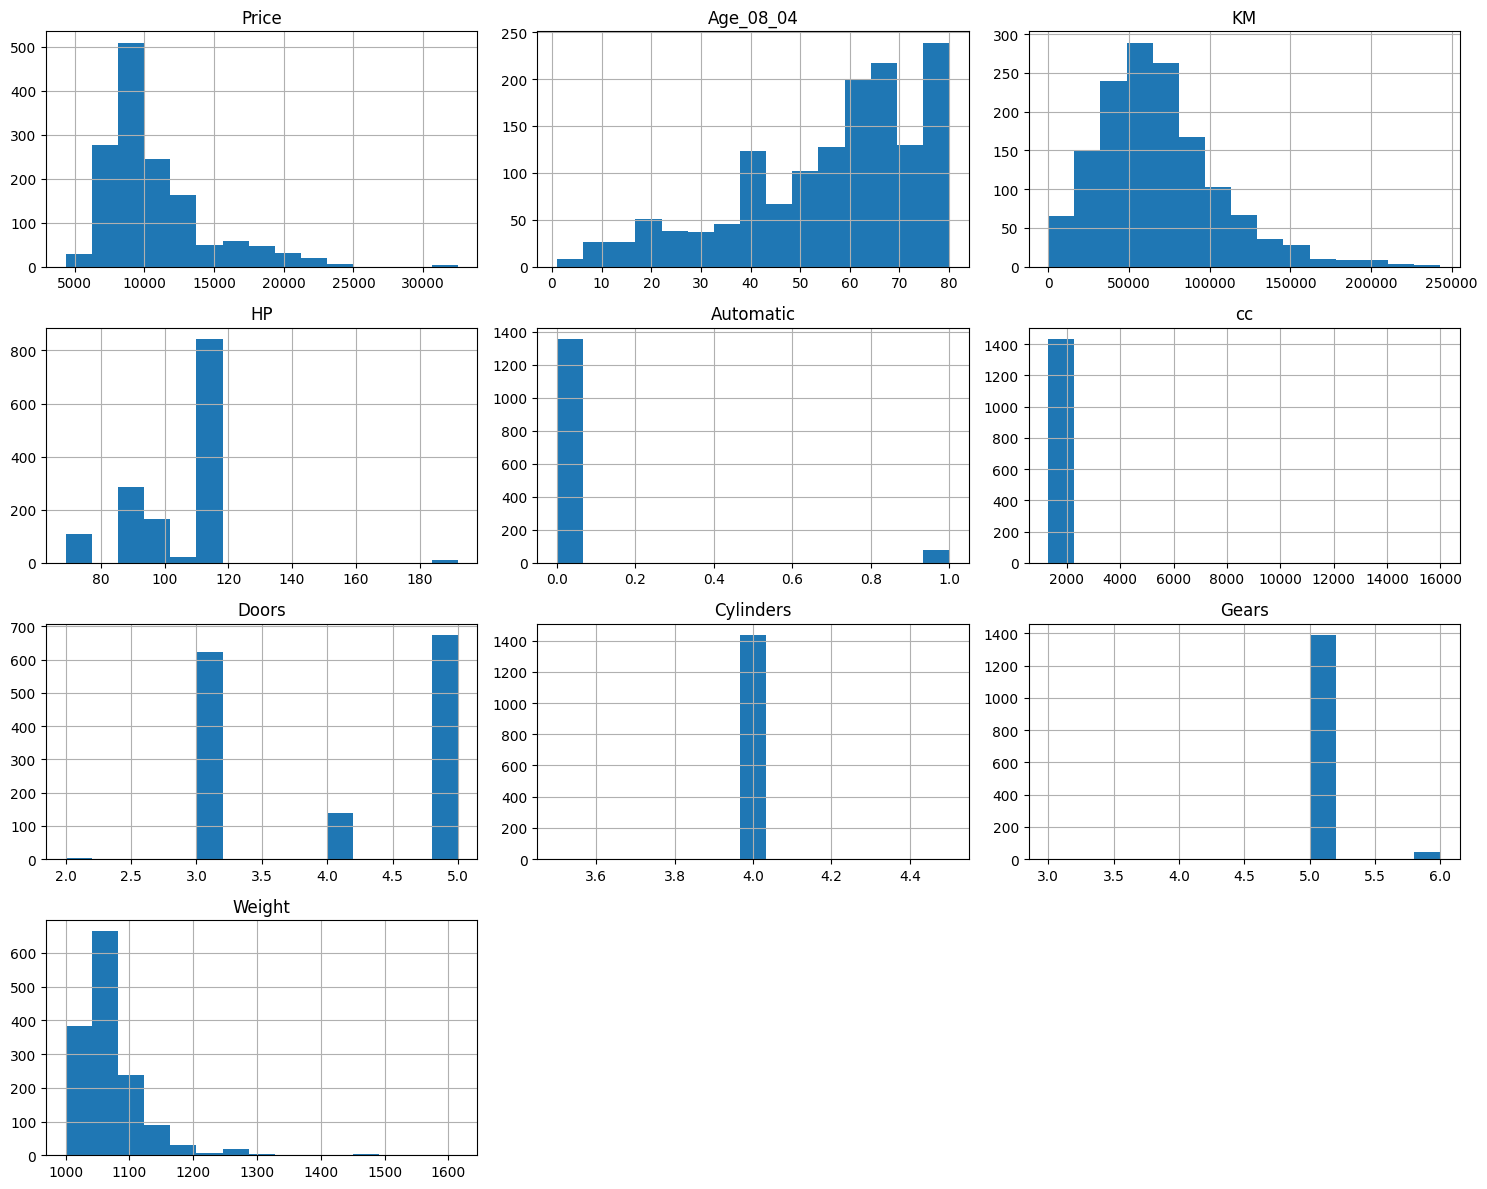

In [4]:

# Histograms

df.hist(figsize=(15,12), bins=15)
plt.tight_layout()
plt.show()


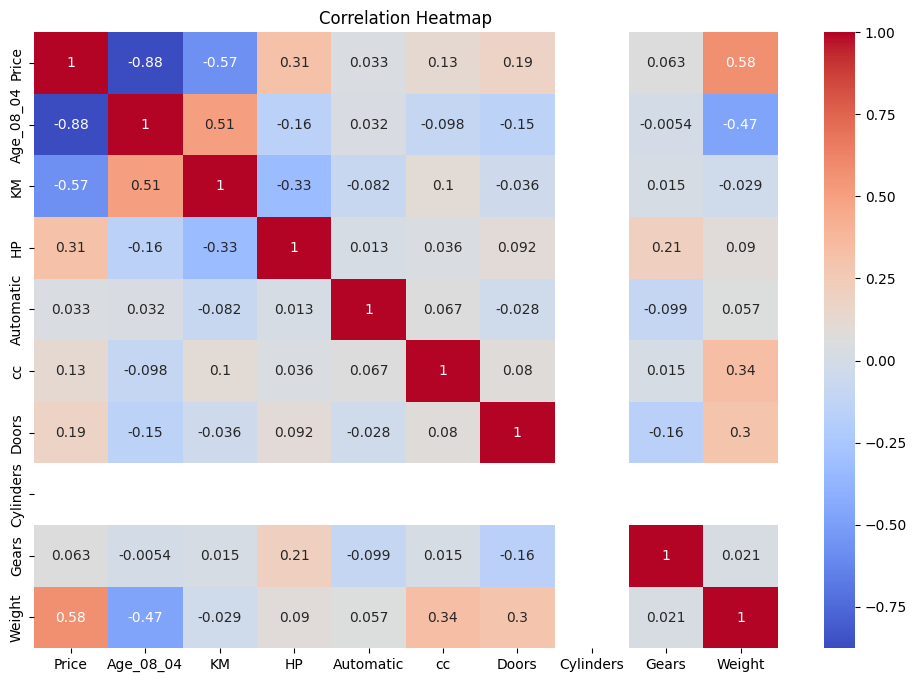

In [5]:

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


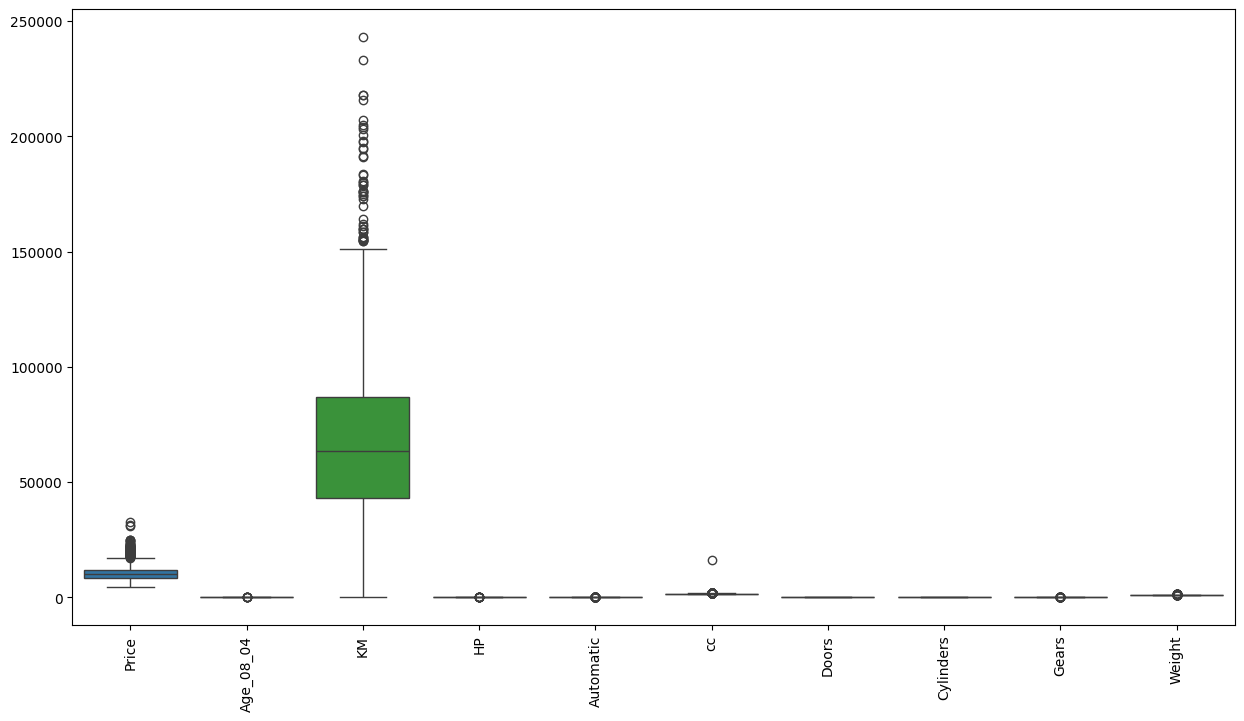

In [6]:

# Boxplots

plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()


In [7]:

# Convert Categorical Variables into Dummy Variables

df = pd.get_dummies(df, drop_first=True)

df.head()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [8]:

# Features and Target Variable

X = df.drop("Price", axis=1)
y = df["Price"]



# Normalization and Standardization

Standardization scales the data so that features have mean 0 and standard deviation 1.
This improves model performance and training stability.


In [9]:

# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [10]:

# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (1148, 11)
Testing Data Shape: (288, 11)



# Model 1: Multiple Linear Regression


In [11]:

# Build Multiple Linear Regression Model

mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

# Predictions
y_pred = mlr_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 990.8872739193968
MSE: 2203043.823143705
RMSE: 1484.2654153296521
R2 Score: 0.834888804061108


In [12]:

# Model Coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr_model.coef_
})

coefficients


,Feature,Coefficient
0,Age_08_04,-2.246662e+03
1,KM,-6.085706e+02
2,HP,2.102533e+02
3,Automatic,3.413608e+01
4,cc,-1.288507e+01
5,Doors,-5.743684e+01
6,Cylinders,-4.547474e-13
7,Gears,1.039463e+02
8,Weight,1.362139e+03
9,Fuel_Type_Diesel,-2.127088e+01



# Model 2: Ridge Regression


In [13]:

# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

# Evaluation
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 Score:", ridge_r2)


Ridge R2 Score: 0.8350658145414689



# Model 3: Lasso Regression


In [14]:

# Lasso Regression

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

# Evaluation
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R2 Score:", lasso_r2)


Lasso R2 Score: 0.8349119754675461


In [15]:

# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

comparison


,Model,R2 Score
0,Multiple Linear Regression,0.834889
1,Ridge Regression,0.835066
2,Lasso Regression,0.834912



# Interview Questions

## 1. What is Normalization & Standardization and how is it helpful?

- Normalization scales data between 0 and 1.
- Standardization transforms data to have mean 0 and standard deviation 1.
- These techniques improve model performance, training speed, and stability.

## 2. What techniques can be used to address multicollinearity in multiple linear regression?

Techniques include:
- Removing highly correlated variables
- Using Ridge Regression
- Using Lasso Regression
- Principal Component Analysis (PCA)
- Feature Selection methods



# Conclusion

This assignment successfully performed:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Multiple Linear Regression
- Ridge Regression
- Lasso Regression
- Model evaluation using regression metrics

The models were compared using R² score to determine performance.
